# 04 — Final Test Analysis (the spine)

The conclusive notebook. Everything before this was decided on the tuning and robustness samples; here the untouched 1000-loan test set (`test_batch.csv`) is loaded and scored exactly once.

What it reports, all on the held-out test set:
- **Performance** — AUC, F1, and recall on the *Charged Off* class, GPT-5.4 vs XGBoost.
- **Real financial P&L** — actual LendingClub cashflows (money in and out per loan), not made-up portfolio assumptions. A short hypothetical-portfolio what-if sits alongside it.
- **Explainability** — SHAP attributions (XGBoost) next to GPT-5.4's natural-language rationale.
- **Error overlap** — do the two models fail on the same loans?

Decisions baked in:
- No threshold tuning. Phase 1 (`01e`) showed GPT-5.4's logprobs are saturated (confidence ~0.96–0.99 whether right or wrong, conf-gap 0.03), so moving the decision threshold buys almost nothing. We report the raw 0/1 output and say so.
- Two finalists, not one: the Phase-2 F1/AUC leaders `baseline` and `chain_of_thought`, both at high reasoning effort (`01d` found high best). The 1000-loan test set breaks the n=100 tie.
- Load-if-exists everywhere. The test set and the expensive LLM predictions are cached to disk, so re-running the notebook loads them instead of spending API budget.

## Setup

In [1]:
import sys; sys.path.insert(0, '..')
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score)
from IPython.display import display

from llm_utils import (
    run_ml_on_sample, encode_for_ml, run_llm_experiment,
    build_user_prompt, format_loan_features, evaluate_predictions,
    DATA_DIR, RESULTS_DIR, MODEL_DIR,
)
from sample_generation import get_test_batch

load_dotenv('../.env', override=False)
MODEL   = 'gpt-5.4'
API_KEY = os.getenv('OPENAI_API_KEY')

# Extra keys widen throughput for the 1000-loan parallel run. Add OPENAI_API_KEY_2 /
# _3 to .env and they're picked up automatically; falls back to the single key.
from llm_utils import load_all_api_keys
API_KEYS = load_all_api_keys('openai')
MAX_WORKERS = max(1, len(API_KEYS) * 4)           # ~4 concurrent calls per key
print(f'{len(set(API_KEYS))} OpenAI key(s) -> {MAX_WORKERS} parallel workers')

FORCE_RERUN = False                              # True = re-call the API even if cached
PRED_PATH   = f'{RESULTS_DIR}/04_test_predictions.csv'
print('Cached predictions exist:', os.path.exists(PRED_PATH))

10 OpenAI key(s) -> 40 parallel workers
Cached predictions exist: True


## Step 1 — The held-out test set (load-if-exists)

Same pattern as the other samples: `get_test_batch()` returns the committed
1000-loan `test_batch.csv` if it exists, otherwise regenerates it deterministically
(seed 2024) from the held-out XGBoost test split — drawn from the **full** split
(no `desc` restriction) so it is representative of the real portfolio, and carrying
realized-cashflow columns for the financial analysis. Pass `force=True` to rebuild
from the raw file.

In [2]:
test   = get_test_batch()            # n=1000, require_desc=False, +cashflow cols
y_test = test['loan_status'].values
n_co   = int((y_test == 0).sum())
print(f'Test set: {len(test)} loans | Charged Off {n_co} ({n_co/len(test):.1%}) '
      f'| Fully Paid {len(test)-n_co}')
print('Realized-cashflow cols:',
      [c for c in ['funded_amnt','total_pymnt','total_rec_prncp','recoveries',
                   'collection_recovery_fee'] if c in test.columns])

Test set: 1000 loans | Charged Off 160 (16.0%) | Fully Paid 840
Realized-cashflow cols: ['funded_amnt', 'total_pymnt', 'total_rec_prncp', 'recoveries', 'collection_recovery_fee']


## Step 2 — Finalists

Phase 1 (`01d`) picked **`reasoning_effort='high'`**. Phase 2 (`02b`) F1/AUC leaders were
**`baseline`** (F1 0.387) and **`chain_of_thought`** (F1 0.370, AUC 0.645) — statistically
a tie at n=100. We run **both at high effort** on the 1000-loan test set and let the
larger sample adjudicate. Comment one out to run a single finalist.

(Prompts are lifted verbatim from `02b_Prompt_Variance.ipynb`. If they ever drift, the
clean fix is to move `PROMPT_VARIANTS` into a shared `prompt_variants.py` and import it
in both notebooks.)

In [3]:
_JSON_INSTRUCTION = (
    "\n\nRespond ONLY with valid JSON in this exact format:\n"
    '{"prediction": <1 or 0>, "reasoning": "<brief explanation>"}\n\n'
    "Where:\n"
    "- prediction: 1 = Fully Paid, 0 = Charged Off\n"
    "- reasoning: 1-2 sentence explanation of your prediction"
)

COT_SYSTEM = (
    "You are a credit risk analyst. "
    "Before predicting loan outcomes, reason step by step through the evidence. "
    "Identify the key risk signals, weigh them against protective factors, "
    "then arrive at a final prediction."
    + _JSON_INSTRUCTION.replace(
        "1-2 sentence explanation of your prediction",
        "step-by-step analysis: risk signals, protective factors, and conclusion",
    )
)

FINALISTS = [
    dict(name='baseline',
         system_prompt=None,            # None -> build_system_prompt()
         user_prompt_fn=None,           # None -> build_user_prompt(row, include_desc=False)
         reasoning_effort='high'),
    dict(name='chain_of_thought',
         system_prompt=COT_SYSTEM,
         user_prompt_fn=lambda row: (
             "Analyze this loan step by step and predict its outcome:\n\n"
             + format_loan_features(row, include_desc=False)),
         reasoning_effort='high'),
]
print('Finalists:', [f['name'] for f in FINALISTS])

Finalists: ['baseline', 'chain_of_thought']


## Step 3 — Run on the test set (the only cell that spends money)

`run_ml_on_sample` (XGBoost, free) + each finalist on GPT-5.4. Per-loan rows are cached to
`04_test_predictions.csv`; if that file exists and `FORCE_RERUN` is False we load it and
make **zero** API calls. At ~\$0.007/loan high-effort, a full run is ~\$7/finalist but
takes a while (1000 sequential reasoning calls) — let it run in the background once.

In [4]:
# Load-if-exists: if the predictions are already on disk and we're not forcing a
# rerun, load them and make ZERO API calls. This is the only cell that spends money,
# so re-running the notebook is free once the (expensive) test run has completed.
if os.path.exists(PRED_PATH) and not FORCE_RERUN:
    preds_df = pd.read_csv(PRED_PATH)
    print(f'Loaded cached predictions from {PRED_PATH} — no API calls.')
else:
    print('Running XGBoost (free) + finalists on GPT-5.4 (spends $).')
    rows = []

    xgb_probs, xgb_preds = run_ml_on_sample(test)
    for i in range(len(test)):
        rows.append(dict(model='XGBoost', loan_index=i, actual=int(y_test[i]),
                         prediction=int(xgb_preds[i]),
                         prob_fully_paid=float(xgb_probs[i]),
                         reasoning='', cost_usd=0.0))

    for f in FINALISTS:
        print(f"\n=== {f['name']} (high effort) on {len(test)} loans ===")
        r = run_llm_experiment(
            test, api_provider='openai', model_name=MODEL,
            api_keys=API_KEYS, max_workers=MAX_WORKERS,
            use_cache=not FORCE_RERUN,
            label=f"04 final | {f['name']}", include_desc=False, with_logprobs=True,
            system_prompt=f['system_prompt'], user_prompt_fn=f['user_prompt_fn'],
            reasoning_effort=f['reasoning_effort'],
            notebook_id='04_Final_Test_Analysis.ipynb',
            strict=True, max_fail_frac=0.2,
        )
        # Per-loan cost is returned by run_llm_experiment; embed it in the predictions
        # file so cost is derivable from predictions alone (no dependency on llm_calls.csv).
        cost = r.get('cost_usd') or [None] * len(test)
        for i, (p, prob, rea) in enumerate(
                zip(r['predictions'], r['probabilities'], r['reasonings'])):
            c = cost[i] if i < len(cost) else None
            rows.append(dict(model=f"GPT-5.4 ({f['name']})", loan_index=i,
                             actual=int(y_test[i]),
                             prediction=(int(p) if p is not None else np.nan),
                             prob_fully_paid=(float(prob) if prob is not None else np.nan),
                             reasoning=str(rea) if rea is not None else '',
                             cost_usd=(float(c) if c is not None else 0.0)))

    preds_df = pd.DataFrame(rows)
    preds_df.to_csv(PRED_PATH, index=False)

# Model list driving every downstream cell (Steps 4-6): XGBoost first, then each
# GPT-5.4 finalist, in insertion order.
models = list(preds_df['model'].unique())

display(preds_df.groupby('model').size())

Loaded cached predictions from /Users/alemz/Projects/Github/Sabadell_Capstone/data/results/llm/04_test_predictions.csv — no API calls.


model
GPT-5.4 (baseline)            1000
GPT-5.4 (chain_of_thought)    1000
XGBoost                       1000
dtype: int64

## Step 4 — Performance

AUC / F1 / precision / recall on the *Charged Off* class, at the raw 0/1 output (no
threshold tuning — see the intro). XGBoost test AUC ≈ 0.705 is the bar to clear.

In [5]:
def metrics_for(model_name):
    d = preds_df[preds_df['model'] == model_name].sort_values('loan_index')
    m = d['prediction'].notna()
    yt = d.loc[m, 'actual'].astype(int).values
    yp = d.loc[m, 'prediction'].astype(int).values
    # AUC over the rows that actually have a probability. LLM logprobs can be
    # sparse (or absent under high reasoning effort); one missing value shouldn't
    # void the whole AUC, so we compute it on the rows that do have a probability.
    prob = pd.to_numeric(d.loc[m, 'prob_fully_paid'], errors='coerce').values
    pm = ~np.isnan(prob)
    auc = (roc_auc_score(yt[pm], prob[pm])
           if pm.sum() >= 2 and len(np.unique(yt[pm])) == 2 else np.nan)
    return dict(model=model_name, n=int(m.sum()), n_auc=int(pm.sum()),
                accuracy=accuracy_score(yt, yp),
                precision_CO=precision_score(yt, yp, pos_label=0, zero_division=0),
                recall_CO=recall_score(yt, yp, pos_label=0, zero_division=0),
                f1_CO=f1_score(yt, yp, pos_label=0, zero_division=0),
                auc=auc)

perf = pd.DataFrame([metrics_for(m) for m in models]).set_index('model')
perf.to_csv(f'{RESULTS_DIR}/04_test_performance.csv')
display(perf.style.format({'accuracy': '{:.3f}', 'precision_CO': '{:.3f}',
                           'recall_CO': '{:.3f}', 'f1_CO': '{:.3f}', 'auc': '{:.3f}'},
                          na_rep='n/a'))

,n,n_auc,accuracy,precision_CO,recall_CO,f1_CO,auc
model,,,,,,,
XGBoost,1000,1000,0.688,0.279,0.600,0.381,0.706
GPT-5.4 (baseline),1000,0,0.764,0.284,0.312,0.298,n/a
GPT-5.4 (chain_of_thought),1000,0,0.775,0.270,0.237,0.252,n/a


## Step 5 — Decision P&L on actual LendingClub cashflows (case-by-case)

The honest money question, priced **decision-by-decision** on realized cashflows —
including the opportunity cost of turning away a good borrower:

| decision | actually Paid | actually Charged Off |
|---|---|---|
| **Approve** | `+ total_rec_int` (interest earned) | `total_pymnt + recoveries - collection_recovery_fee - funded_amnt` (realized loss) |
| **Reject**  | `- total_rec_int` (interest foregone) | `0` (loss avoided) |

A model predicting **Fully Paid (1)** = *approve*; **Charged Off (0)** = *reject*.
Portfolio P&L sums these per-loan outcomes. Unlike a naive view where rejecting
anything scores zero, an **over-conservative model is penalised** for the good loans
it declines. We compare each model against **approve-everyone**, **reject-everyone**,
and an **oracle** that approves only the loans that truly paid (= the total interest
income of the whole book).

In [6]:
# Case-by-case decision P&L on actual LendingClub cashflows. Every decision has a
# realized consequence, including the opportunity cost of declining a good borrower:
#   approve & paid    -> +interest (total_rec_int)
#   approve & default -> total_pymnt + recoveries - collection_recovery_fee - funded_amnt
#   reject  & paid    -> -interest (foregone)
#   reject  & default -> 0 (loss avoided)
interest = test['total_rec_int'].fillna(0).values
net_loss = (test['total_pymnt'].fillna(0) + test['recoveries'].fillna(0)
            - test['collection_recovery_fee'].fillna(0)
            - test['funded_amnt'].fillna(test['loan_amnt'])).values

def model_costs(model_name):
    """API $ for this model, summed from per-loan cost embedded in the predictions
    file (XGBoost = 0). No dependency on llm_calls.csv."""
    d = preds_df[preds_df['model'] == model_name]
    if 'cost_usd' not in d.columns:
        return 0.0
    return float(pd.to_numeric(d['cost_usd'], errors='coerce').fillna(0).sum())

def case_pnl(pred):
    pred = np.asarray(pred).astype(int)
    ap = (pred == 1) & (y_test == 1)    # approve & paid    -> +interest
    ad = (pred == 1) & (y_test == 0)    # approve & default -> realized net_loss
    rp = (pred == 0) & (y_test == 1)    # reject  & paid    -> -interest (opportunity cost)
    # reject & default -> 0 (loss avoided)
    return dict(approve_paid_income=interest[ap].sum(),
                approve_default_loss=net_loss[ad].sum(),
                reject_paid_oppcost=-interest[rp].sum(),
                total_pnl=interest[ap].sum() + net_loss[ad].sum() - interest[rp].sum(),
                n_approved=int((pred == 1).sum()))

rows = []
for m in models:
    d = preds_df[preds_df['model'] == m].sort_values('loan_index')
    r = case_pnl(d['prediction'].values)
    r['api_cost'] = model_costs(m)
    r['pnl_after_api'] = r['total_pnl'] - r['api_cost']
    rows.append(dict(model=m, **r))
for name, pred in [('Approve everyone', np.ones_like(y_test)),
                   ('Reject everyone',  np.zeros_like(y_test)),
                   ('Oracle (perfect)', y_test)]:
    r = case_pnl(pred)
    r['api_cost'] = 0.0
    r['pnl_after_api'] = r['total_pnl']
    rows.append(dict(model=name, **r))

pnl = pd.DataFrame(rows).set_index('model')
pnl.to_csv(f'{RESULTS_DIR}/04_test_financials.csv')
_money = {c: '${:,.0f}' for c in pnl.columns if c != 'n_approved'}
display(pnl.style.format(_money, na_rep='n/a'))
print('\nRejecting a good borrower costs the foregone interest, so an over-conservative '
      'model is penalised. Oracle = total interest income of the book; reject-everyone = '
      'the full opportunity cost of lending to nobody. API cost is ~5 orders of magnitude '
      'below the credit P&L (the 01f insight).')

,approve_paid_income,approve_default_loss,reject_paid_oppcost,total_pnl,n_approved,api_cost,pnl_after_api
model,,,,,,,
XGBoost,"$1,447,564","$-223,249","$-1,317,857","$-93,541",656,$0,"$-93,541"
GPT-5.4 (baseline),"$2,112,585","$-460,902","$-652,836","$998,848",824,$6,"$998,841"
GPT-5.4 (chain_of_thought),"$2,224,721","$-495,502","$-540,699","$1,188,520",859,$11,"$1,188,509"
Approve everyone,"$2,765,421","$-690,850",$-0,"$2,074,571",1000,$0,"$2,074,571"
Reject everyone,$0,$0,"$-2,765,421","$-2,765,421",0,$0,"$-2,765,421"
Oracle (perfect),"$2,765,421",$0,$-0,"$2,765,421",840,$0,"$2,765,421"



Rejecting a good borrower costs the foregone interest, so an over-conservative model is penalised. Oracle = total interest income of the book; reject-everyone = the full opportunity cost of lending to nobody. API cost is ~5 orders of magnitude below the credit P&L (the 01f insight).


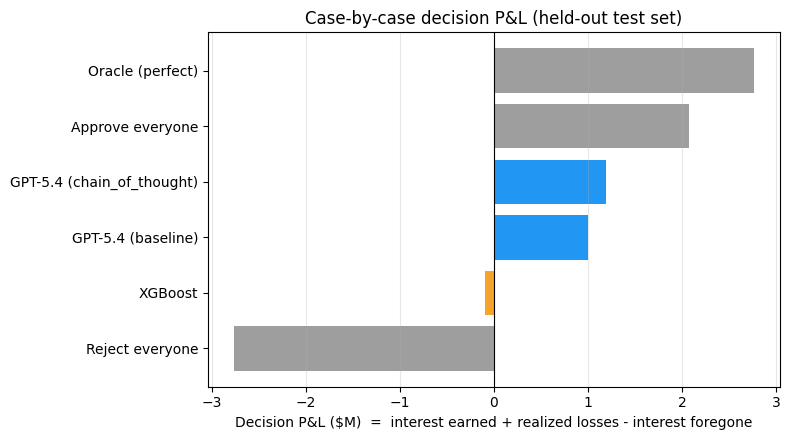

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
order = pnl['total_pnl'].sort_values()
base = ('Approve everyone', 'Reject everyone', 'Oracle (perfect)')
colors = ['#2196f3' if 'GPT' in m else '#9e9e9e' if m in base else '#f4a529' for m in order.index]
ax.barh(range(len(order)), order.values / 1e6, color=colors)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order.index)
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('Decision P&L ($M)  =  interest earned + realized losses - interest foregone')
ax.set_title('Case-by-case decision P&L (held-out test set)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/04_test_pnl.png', dpi=150, bbox_inches='tight')
plt.show()

### Brief: hypothetical-portfolio simulation (made-up assumptions)

Kept short for the deck's "scale this up" framing. Unlike Step 5, these are **not** real
dollars — they project each model's test-set error profile onto an illustrative
10k-loan book.

In [8]:
PORTFOLIO_SIZE = 10_000
AVG_LOAN       = 15_000
DEFAULT_RATE   = float((y_test == 0).mean())
LGD            = 0.65        # fraction of principal lost on a default
MARGIN         = 0.08        # net profit on a good loan

defaults  = PORTFOLIO_SIZE * DEFAULT_RATE
goods     = PORTFOLIO_SIZE - defaults
sim_rows  = []
for m in models:
    r = perf.loc[m]
    rec, prec = r['recall_CO'], r['precision_CO']
    tp = defaults * rec                       # defaults correctly rejected
    fn = defaults - tp                        # defaults wrongly approved -> loss
    fp = (tp / prec - tp) if prec > 0 else 0  # goods wrongly rejected -> lost profit
    loss_missed = fn * AVG_LOAN * LGD
    lost_profit = fp * AVG_LOAN * MARGIN
    sim_rows.append(dict(model=m, missed_default_loss=loss_missed,
                         lost_profit_rejections=lost_profit,
                         total_cost=loss_missed + lost_profit))
sim = pd.DataFrame(sim_rows).set_index('model')
display(sim.style.format('${:,.0f}'))

,missed_default_loss,lost_profit_rejections,total_cost
model,,,
XGBoost,"$6,240,000","$2,976,000","$9,216,000"
GPT-5.4 (baseline),"$10,725,000","$1,512,000","$12,237,000"
GPT-5.4 (chain_of_thought),"$11,895,000","$1,236,000","$13,131,000"


## Step 6 — Explainability: SHAP (XGBoost) vs LLM rationale

The brief's explainability comparison: XGBoost gives **quantitative per-feature SHAP
attributions**; GPT-5.4 gives a **natural-language rationale** for the same loan.

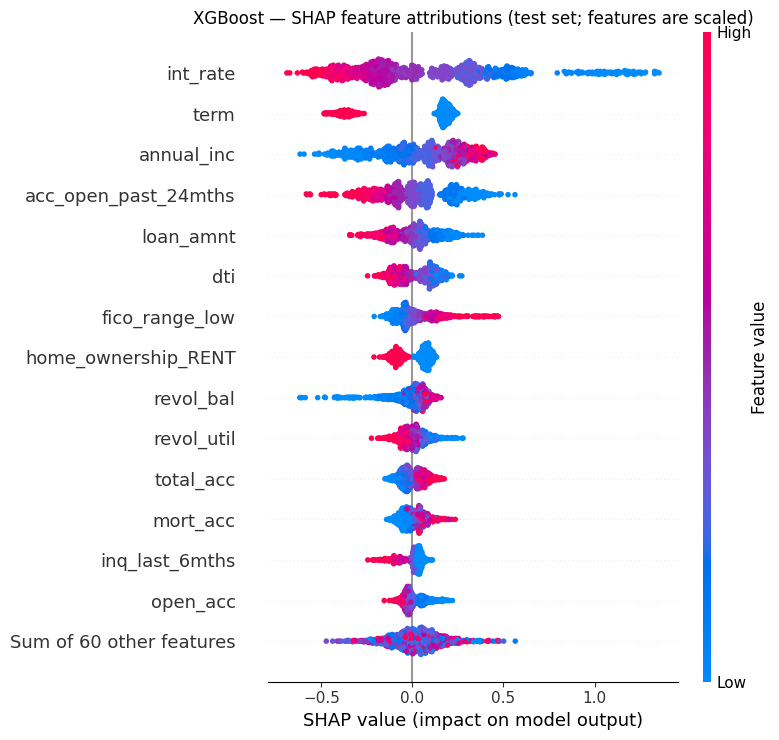

In [9]:
try:
    import shap
    X_test, xgb_model, _ = encode_for_ml(test)
    explainer = shap.TreeExplainer(xgb_model)
    sv = explainer(X_test)
    shap.plots.beeswarm(sv, max_display=15, show=False)
    plt.title('XGBoost — SHAP feature attributions (test set; features are scaled)')
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/04_shap_beeswarm.png', dpi=150, bbox_inches='tight')
    plt.show()
except ImportError:
    print('shap not installed — `pip install shap` to render the attribution plot.')

In [10]:
# GPT-5.4's rationale for loan 0 — the qualitative counterpart to the SHAP plot above.
llm_models_avail = [m for m in models if m.startswith('GPT')]
if llm_models_avail:
    ex = preds_df[preds_df['model'] == llm_models_avail[0]].sort_values('loan_index').iloc[0]
    print(f"Loan 0 | actual = {'Fully Paid' if ex['actual']==1 else 'Charged Off'} "
          f"| {llm_models_avail[0]} predicted "
          f"{'Fully Paid' if ex['prediction']==1 else 'Charged Off'}\n")
    print('Rationale:', ex['reasoning'])

Loan 0 | actual = Charged Off | GPT-5.4 (baseline) predicted Charged Off

Rationale: Despite the low DTI and long credit history, this application carries several strong default signals: a very high interest rate, a low LendingClub grade of F3, a large 60-month loan, and a recent delinquency. The middling FICO score and recent credit issues outweigh the otherwise stable income and employment profile.


## Step 7 — Error overlap

Do XGBoost and the best LLM finalist fail on the **same** loans? If they share most
errors, the dataset (not the model class) is the ceiling — the working hypothesis from
the progress report.

In [11]:
llm_best = perf.drop(index='XGBoost', errors='ignore')['f1_CO'].idxmax()
xgb = preds_df[preds_df['model'] == 'XGBoost'].set_index('loan_index')
llm = preds_df[preds_df['model'] == llm_best].set_index('loan_index')
j = xgb[['actual', 'prediction']].join(llm[['prediction']], rsuffix='_llm').dropna()

xgb_right = j['prediction'] == j['actual']
llm_right = j['prediction_llm'] == j['actual']
print(f'Head-to-head: XGBoost vs {llm_best}  (n={len(j)})')
print(f'  both right     : {(xgb_right & llm_right).sum()}')
print(f'  both wrong     : {(~xgb_right & ~llm_right).sum()}')
print(f'  XGBoost only   : {(xgb_right & ~llm_right).sum()}')
print(f'  LLM only       : {(~xgb_right & llm_right).sum()}')
co = j[j['actual'] == 0]
print(f'\nCharged Off loans (n={len(co)}): caught by XGBoost '
      f'{int((co["prediction"]==0).sum())}, by LLM {int((co["prediction_llm"]==0).sum())}, '
      f'by both {int(((co["prediction"]==0) & (co["prediction_llm"]==0)).sum())}')

Head-to-head: XGBoost vs GPT-5.4 (baseline)  (n=1000)
  both right     : 606
  both wrong     : 154
  XGBoost only   : 82
  LLM only       : 158

Charged Off loans (n=160): caught by XGBoost 96, by LLM 50, by both 41


## Step 8 — Statistical significance (no API calls)

Turns the point estimates above into defensible claims. Two tools:

- **McNemar's test** (paired, exact): both models scored the *same* 1000 loans, so only the
  loans where exactly one model is right carry information. If the two were equally good,
  those disagreements would split ~50/50; the binomial p-value says how surprising the
  observed split is. This is the right test for "is the accuracy gap real or luck?".
- **Bootstrap 95% confidence intervals**: resample the 1000 test loans with replacement
  10,000 times and recompute each metric; the middle 95% of the resampled values shows how
  much the number moves with the luck of the draw. Reported for accuracy, Charged-Off F1,
  and the decision P&L.

Everything here reads the already-saved predictions — zero API calls, and the test set is
not re-scored, so the touched-once protocol is intact. → `04_significance.csv`

In [12]:
from scipy.stats import binomtest

rng = np.random.default_rng(42)
N_BOOT = 10_000

wide = preds_df.pivot(index='loan_index', columns='model', values='prediction').sort_index()
y = preds_df[preds_df['model'] == 'XGBoost'].sort_values('loan_index')['actual'].values

def f1_co(yt, yp):
    tp = ((yt == 0) & (yp == 0)).sum()
    fp = ((yt == 1) & (yp == 0)).sum()
    fn = ((yt == 0) & (yp == 1)).sum()
    return 2 * tp / (2 * tp + fp + fn) if tp else 0.0

def pnl_contrib(pred):
    """Per-loan realized P&L for a 0/1 decision vector (same rules as Step 5)."""
    pred = np.asarray(pred).astype(int)
    return np.where(pred == 1,
                    np.where(y == 1, interest, net_loss),
                    np.where(y == 1, -interest, 0.0))

# One shared set of bootstrap index draws so every model is resampled identically.
boot_idx = rng.integers(0, len(y), size=(N_BOOT, len(y)))

rows = []
for m in models:
    yp = wide[m].values.astype(int)
    contrib = pnl_contrib(yp)
    accs = (y[boot_idx] == yp[boot_idx]).mean(axis=1)
    pnls = contrib[boot_idx].sum(axis=1)
    # F1 needs a loop (set-based counts); 4000 resamples keep it fast and stable.
    f1s = np.array([f1_co(y[s], yp[s]) for s in boot_idx[:4000]])

    # McNemar vs XGBoost (skipped for XGBoost itself)
    if m == 'XGBoost':
        b = c = None; p_mcnemar = np.nan
    else:
        xp = wide['XGBoost'].values.astype(int)
        m_right, x_right = (yp == y), (xp == y)
        b = int((m_right & ~x_right).sum())    # this model right, XGBoost wrong
        c = int((~m_right & x_right).sum())    # XGBoost right, this model wrong
        p_mcnemar = binomtest(b, b + c, 0.5).pvalue

    rows.append(dict(
        model=m,
        accuracy=(y == yp).mean(),
        acc_lo=np.percentile(accs, 2.5), acc_hi=np.percentile(accs, 97.5),
        f1_CO=f1_co(y, yp),
        f1_lo=np.percentile(f1s, 2.5), f1_hi=np.percentile(f1s, 97.5),
        total_pnl=contrib.sum(),
        pnl_lo=np.percentile(pnls, 2.5), pnl_hi=np.percentile(pnls, 97.5),
        win_vs_xgb=b, loss_vs_xgb=c, mcnemar_p_vs_xgb=p_mcnemar,
    ))

sig = pd.DataFrame(rows).set_index('model')
sig.to_csv(f'{RESULTS_DIR}/04_significance.csv')
display(sig.style.format({
    'accuracy': '{:.3f}', 'acc_lo': '{:.3f}', 'acc_hi': '{:.3f}',
    'f1_CO': '{:.3f}', 'f1_lo': '{:.3f}', 'f1_hi': '{:.3f}',
    'total_pnl': '${:,.0f}', 'pnl_lo': '${:,.0f}', 'pnl_hi': '${:,.0f}',
    'mcnemar_p_vs_xgb': '{:.2e}'}, na_rep='—'))

for m in models:
    if m == 'XGBoost':
        continue
    r = sig.loc[m]
    print(f"\n{m} vs XGBoost — of the loans where exactly one is right, "
          f"{m.split('(')[-1].rstrip(')')} wins {int(r.win_vs_xgb)} to {int(r.loss_vs_xgb)} "
          f"(McNemar p = {r.mcnemar_p_vs_xgb:.1e}).")
print('\nReading the CIs: accuracy intervals that do not overlap XGBoost\'s = a solid win; '
      'note the Charged-Off F1 intervals point the OTHER way (XGBoost catches defaults '
      'better) — the two headline claims must be stated separately.')

,accuracy,acc_lo,acc_hi,f1_CO,f1_lo,f1_hi,total_pnl,pnl_lo,pnl_hi,win_vs_xgb,loss_vs_xgb,mcnemar_p_vs_xgb
model,,,,,,,,,,,,
XGBoost,0.688,0.660,0.716,0.381,0.325,0.434,"$-93,541","$-376,751","$182,997",—,—,—
GPT-5.4 (baseline),0.764,0.738,0.790,0.298,0.233,0.364,"$998,848","$706,168","$1,292,427",158.000000,82.000000,1.06e-06
GPT-5.4 (chain_of_thought),0.775,0.749,0.801,0.252,0.188,0.318,"$1,188,520","$896,157","$1,477,420",177.000000,90.000000,1.10e-07



GPT-5.4 (baseline) vs XGBoost — of the loans where exactly one is right, baseline wins 158 to 82 (McNemar p = 1.1e-06).

GPT-5.4 (chain_of_thought) vs XGBoost — of the loans where exactly one is right, chain_of_thought wins 177 to 90 (McNemar p = 1.1e-07).

Reading the CIs: accuracy intervals that do not overlap XGBoost's = a solid win; note the Charged-Off F1 intervals point the OTHER way (XGBoost catches defaults better) — the two headline claims must be stated separately.


## Verdict

On the held-out 1000 loans the two model families pull in different directions:

- **Charged-Off F1 / AUC:** XGBoost still wins — F1 0.381, AUC 0.706. GPT-5.4 sits lower on F1 (baseline 0.298, chain-of-thought 0.252) and has no usable AUC, since its logprobs are saturated (no calibration or threshold lever to pull).
- **Money:** GPT-5.4 wins decisively on realized cashflows. Baseline nets about +$1.0M over the book and chain-of-thought about +$1.19M, against XGBoost at roughly −$94k — GPT approves a wider slice of borrowers that mostly do pay. The API cost (single-digit dollars over 1000 loans) is a rounding error next to that.
- **Significance (Step 8):** the accuracy gap is not luck — GPT-5.4 wins the paired disagreements roughly 2:1 (baseline 158–82, CoT 177–90; McNemar p ≈ 1e-6 and 1e-7), and the bootstrap accuracy intervals clear XGBoost's without overlap. The F1 intervals lean the other way, so the honest headline is two separate claims: *GPT-5.4 is the significantly better decision-maker; XGBoost remains the better default-catcher.*
- **Explainability:** SHAP gives per-feature, quantitative attributions; the LLM gives a readable per-loan rationale. They suit different audiences, and both are defensible.
- **Shared errors:** 154 of the 1000 loans are missed by both models, and only 41 of the 160 true Charged Offs are caught by both. Most of the error is common to both, which backs the progress-report hypothesis that the structured features, not the model class, are the ceiling.